<a target="_blank" href="https://colab.research.google.com/github/bmalcover/AppOC/blob/main/docs/notebooks/04_Images/02_Image.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Image models

<div class="alert alert-warning">     
<b> Table of Contents </b>

1. [Image models](#im_mod)
2. [Transfer learning](#tra_lr)
    


In the previous notebook, we discovered how to **handle image data efficiently** using PyTorch's `Dataset` and `DataLoader` tools. We learned to organize image data in folder structures, apply transformations on-the-fly, and load batches of images for training.

Now that we know how to prepare and load image data, the next step is to learn about **machine learning models specifically designed for images**. In this notebook, we will explore **Convolutional Neural Networks (CNNs)** and **transfer learning** -powerful techniques that exploit the spatial structure of images to achieve state-of-the-art results in computer vision tasks.


<div class="alert alert-warning">
    <b> I. <i>Image models</i></b>
    <a id="im_mod"></a>
</div>


Until now we have used MLPs (Multi-Layer Perceptrons). MLPs are **fully connected networks** that expect their input as a **1D tabular dataset** -meaning all data must be flattened into a single vector. When we flatten 2D image data into a 1D array, we lose the spatial structure of the image. In the previous example, we had to flatten the data, which results in:

In [1]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms

BATCH_SIZE = 10

# Load CIFAR-10 dataset
transform = transforms.ToTensor()
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform) # download must be True if is the first time you execute this notebook

# Load the entire dataset into memory
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=False)
images, labels = next(iter(trainloader))
print(images.shape)

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


torch.Size([10, 3, 32, 32])


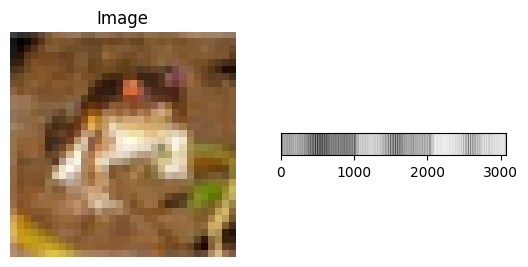

In [2]:
from matplotlib import pyplot as plt
import numpy as np


plt.subplot(1, 2, 1)
plt.title("Image")
plt.imshow(images[0].permute((1, 2, 0)))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(np.hstack(([images[0].flatten()] * 300)).reshape(300, -1), cmap="Greys");  # To improve the width
plt.yticks([]);

As you can see it we make a complex problem even worse. Now that we're working with image we need models that can understand **spatial patterns** in images -such as edges, textures, and shapes. This is where **Convolutional Neural Networks (CNNs)** come in.

---

CNNs are a special class of neural networks designed specifically for processing **grid-like data**, such as images. Unlike traditional fully connected networks, CNNs take advantage of the **2D structure** of images. They can recognize patterns that occur in small regions of an image and reuse that knowledge across the whole image. They were first introduce in the 80s by [LeCun *et al.*](https://ieeexplore.ieee.org/abstract/document/6795724) alongside the `MNIST` dataset. A CNN has two main parts:

<img src="https://github.com/bmalcover/AppOC/blob/main/docs/_static/04/cnn.png?raw=1" width="500" />


### Key Building Blocks of a CNN

1. **Convolutional Layers**: These layers use learnable **filters (kernels)** that slide over the input (e.g., an image) to extract local features such as edges, textures, or shapes. Each filter generates a corresponding **feature map** that highlights the presence of specific patterns across the spatial dimensions.

2. **Pooling Layers**. These layers **downsample** the feature maps by summarizing small regions (e.g., taking the max value). Pooling helps reduce the spatial size and the number of parameters, making the model faster and more robust.

3. **Predictor**. We can use any machine learning model after the convolutional part. We usually use a MLP.

**The most important thing to take into account**: The bigger the better!

Let's load our first CNN!:


In [3]:
import torchvision.models as models

# Load pretrained ResNet50 model
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.eval()  # Set to evaluation mode (disables dropout, batch norm, etc.)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

**TorchVision** is an official library that is part of the **PyTorch ecosystem**. It provides:

1. **Pre-trained CNN Models** (`torchvision.models`): Access to state-of-the-art architectures pre-trained on ImageNet, ready to use out-of-the-box:
   - `ResNet`, `VGG`, `Inception`, `DenseNet`, `EfficientNet`, `MobileNet`, `Vision Transformers`, and many more
   - Models come with their **pre-trained weights already downloaded and loaded**
   - You can easily switch between different architectures: `models.resnet50()`, `models.vgg16()`, `models.efficientnet_b0()`, etc.

2. **Image Transforms** (`torchvision.transforms`): A complete pipeline for image preprocessing and data augmentation
   - Resizing, cropping, rotating, flipping, color adjustments, etc.
   - Composition of multiple transforms for efficient data pipelines

3. **Datasets** (`torchvision.datasets`): Easy access to popular computer vision datasets
   - `MNIST`, `CIFAR10`, `CIFAR100`, `ImageNet`, `COCO`, and more

In the code above, we used `torchvision.models.resnet50(weights=...)` which:
- Automatically downloads the pre-trained ResNet50 model architecture
- Loads the weights trained on ImageNet (1000 classes, 14M images)
- Gives us a model ready for **immediate inference or fine-tuning** on our own tasks

This is the power of torchvision -it abstracts away the complexity of downloading, managing, and loading pre-trained models, making transfer learning accessible to everyone.


<div style="color:red; background-color:rgba(255,106,116, 0.4);padding:10px">We must adapt the images to the model!</div>

In [28]:
# Prepare ImageNet normalization transform
imagenet_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

# Get a sample image and prepare it
#sample_image = images[0].clone()  # Take first image from batch
#sample_image_normalized = imagenet_transform(sample_image)
#sample_input = sample_image_normalized.unsqueeze(0)  # Add batch dimension


In [30]:
# Make inference
output = model(sample_input)
top_probs, top_classes = torch.topk(output, 5)

print(top_classes)

tensor([[373,  43, 371, 925, 926]])


To understant the output we must check the Imagenet class [list](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/).

### Exercise

1. Load an image from your compute, apply the transformer and make a prediction with the model. It is correct?

**Note:** To load an image you can use the library PIL:

```python

from PIL import Image

img = Image.open(<path to image>)

```

In [26]:
from PIL import Image
img = Image.open('foto.png')



In [31]:
res = imagenet_transform(img)
output = model(res.unsqueeze(0))


print(top_classes)

RuntimeError: The size of tensor a (4) must match the size of tensor b (3) at non-singleton dimension 0

</div>

<div class="alert alert-warning">
    <b> II. <i>Transfer learning</i></b>
    <a id="tra_l"></a></div>


## Transfer Learning: Plug and Play

The beauty of pre-trained models is **transfer learning** -you can use a model trained on ImageNet for your own task:

### The Superpower of Transfer Learning

1. **Speed**: Train in minutes or hours instead of weeks
2. **Accuracy**: Start from learned features, not random weights
3. **Small Datasets**: Works well even with limited labeled data
4. **Easy to Use**: Load, adapt, train -just a few lines of code

This is why pre-trained models are a game-changer in computer vision. Whether you're classifying animals, detecting objects, or segmenting images, pre-trained models provide an incredible starting point.

Let's see how we can do it. We will modify our ResNet50 to work with CIFAR10. There are a set of steps we must do:

1. Load the model and change the last layer. This will make that the prediction is the one we desired:

In [32]:
# Fine-tune ResNet50 on CIFAR10

# Load pretrained ResNet50
resnet_finetuned = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Modify the final classification layer for CIFAR10 (10 classes instead of 1000)
num_classes_cifar10 = 10
resnet_finetuned.fc = torch.nn.Linear(resnet_finetuned.fc.in_features, num_classes_cifar10)

2. We freeze the original layers. When we train the model we want that the first layers remain the same. The first layers detect general patterns (lines, curves, color, etc.).

In [35]:
# Strategy: Freeze early layers, fine-tune later layers
# Early layers capture general features, later layers are task-specific
for name, param in resnet_finetuned.named_parameters():
    if "fc" not in name:
        param.requires_grad = False  # Freeze early layers

3. We train the model. It is the first time to train a CNN it have some differences.

    - First we want to use our GPU, because it is more computationally intensive train a CNN than a MLP.

In [36]:
# Move to device and set to training mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_finetuned = resnet_finetuned.to(device)
resnet_finetuned.train()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Summary: Loss Functions in Machine Learning

A **loss function** (or cost function) is a mathematical tool used to measure the "distance" between a model's predictions and the actual target values. The goal of training is to minimize this value to improve accuracy.

### Core Functions & Use Cases

| Category | Loss Function | Best For... |
| :--- | :--- | :--- |
| **Classification** | **Cross Entropy** | Multi-class tasks (most common). |
| **Classification** | **Binary Cross Entropy** | Two-class tasks (Yes/No). |
| **Regression** | **Mean Squared Error (MSE)** | General regression; penalizes large errors. |
| **Regression** | **Mean Absolute Error (L1)** | Data with outliers; more robust. |


### Key Takeaways
* **Optimization**: Optimizers use the gradients of the loss function to adjust model weights.
* **Numerical Stability**: In PyTorch, using `BCEWithLogitsLoss` is preferred over a manual Sigmoid + BCE combo to prevent mathematical errors.
* **Data Characteristics**: The choice of loss should be driven by your data; for instance, use **L1 Loss** if your dataset is noisy or contains many outliers.
* **Task Alignment**: Classification typically relies on probability-based losses, while regression relies on distance-based metrics.

In our fine-tuning example above, we used `torch.nn.CrossEntropyLoss()` because CIFAR10 is a multi-class classification task with 10 classes.

In [37]:
# Define loss function and optimizer
loss_fn_finetuned = torch.nn.CrossEntropyLoss()
# Use lower learning rate for fine-tuning (we're starting from good weights)
optimizer_finetuned = torch.optim.Adam(
    resnet_finetuned.parameters(),
    lr=0.001
)

We must adapt our data to ImageNet so we load again the dataset and dataloader using the Imagenet transform operations, previously defined.

In [38]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=imagenet_transform) # download must be True if is the first time you execute this notebook

# Load the entire dataset into memory
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

## The CNN Training Loop

The **training loop** is the core of the learning process. Here's what happens in each iteration:

### Step-by-Step Breakdown

1. **For each epoch** (complete pass through the entire dataset):
   - Initialize metrics (loss, accuracy) to track performance

   ```python
    for epoch in range(epochs_finetune):
      running_loss = 0.0
      running_acc = 0.0
   ```

2. **For each batch** from the DataLoader:
   - **Forward Pass**: Feed images through the CNN to get predictions

     ```python
     outputs = model(images)  # CNN predicts classes
     ```
   
   - **Compute Loss**: Calculate how wrong the predictions are compared to true labels

     ```python
     loss = loss_fn(outputs, labels)  # Quantify error
     ```
    - **Backward Pass**: Compute gradients using backpropagation

     ```python
     optimizer.zero_grad()  # Clear previous gradients
     loss.backward()        # Compute gradients via chain rule
     ```
   
   - **Optimizer Step**: Update model weights to reduce loss

     ```python
     optimizer.step()  # Move weights in direction that reduces loss
     ```
   
   - **Track Metrics**: Update running loss and accuracy
   
     ```python
     running_loss += loss.item()
     _, predicted = torch.max(outputs, 1)  # Get highest probability class
     running_acc += (predicted == labels).sum().item() / labels.size(0)
     ```

3. **After each epoch**:
   - Calculate average loss and accuracy
   - Print progress
   - Repeat for next epoch

### Key Concepts

- **Forward Pass**: Data flows through the network to produce predictions
- **Loss Computation**: Measures how far predictions are from ground truth
- **Backward Pass**: Computes gradients showing how to adjust weights
- **Gradient Descent**: Optimizer uses gradients to update weights in the direction that reduces loss
- **Epochs**: Complete passes through the entire dataset; multiple epochs allow the model to learn iteratively


This loop repeats thousands of times, gradually improving model accuracy through incremental weight adjustments.


In [39]:
# Fine-tuning loop
epochs_finetune = 5
for epoch in range(epochs_finetune):
    running_loss = 0.0
    running_acc = 0.0

    for batch_idx, (images, labels) in enumerate(trainloader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = resnet_finetuned(images)
        loss = loss_fn_finetuned(outputs, labels)

        # Backward pass
        optimizer_finetuned.zero_grad()
        loss.backward()
        optimizer_finetuned.step()

        # Metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        running_acc += (predicted == labels).sum().item() / labels.size(0)

        if (batch_idx + 1) % 100 == 0:
            avg_loss = running_loss / (batch_idx + 1)
            avg_acc = running_acc / (batch_idx + 1)
            print(f"Epoch [{epoch+1}/{epochs_finetune}], Step [{batch_idx+1}/{len(trainloader)}], "
                  f"Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}")

    avg_loss = running_loss / len(trainloader)
    avg_acc = running_acc / len(trainloader)
    print(f"Epoch {epoch+1}/{epochs_finetune} completed - Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}\n")

print("Fine-tuning complete!")

Epoch [1/5], Step [100/5000], Loss: 1.9057, Accuracy: 0.3310
Epoch [1/5], Step [200/5000], Loss: 1.6414, Accuracy: 0.4350
Epoch [1/5], Step [300/5000], Loss: 1.5060, Accuracy: 0.4823
Epoch [1/5], Step [400/5000], Loss: 1.4135, Accuracy: 0.5137
Epoch [1/5], Step [500/5000], Loss: 1.3556, Accuracy: 0.5380
Epoch [1/5], Step [600/5000], Loss: 1.3131, Accuracy: 0.5522
Epoch [1/5], Step [700/5000], Loss: 1.2754, Accuracy: 0.5654
Epoch [1/5], Step [800/5000], Loss: 1.2484, Accuracy: 0.5735
Epoch [1/5], Step [900/5000], Loss: 1.2227, Accuracy: 0.5827
Epoch [1/5], Step [1000/5000], Loss: 1.1952, Accuracy: 0.5912
Epoch [1/5], Step [1100/5000], Loss: 1.1704, Accuracy: 0.6005
Epoch [1/5], Step [1200/5000], Loss: 1.1542, Accuracy: 0.6053
Epoch [1/5], Step [1300/5000], Loss: 1.1363, Accuracy: 0.6108
Epoch [1/5], Step [1400/5000], Loss: 1.1228, Accuracy: 0.6142
Epoch [1/5], Step [1500/5000], Loss: 1.1091, Accuracy: 0.6193
Epoch [1/5], Step [1600/5000], Loss: 1.1015, Accuracy: 0.6218
Epoch [1/5], Step

The training loop have become more complex, with a second loop, however, to do a prediction with an already trained model is as easy as in more simple models:

In [40]:
resnet_finetuned(images)

tensor([[-11.0217, -10.7826,  -3.8113,   0.5543,   3.0671,   0.6504,  -4.4980,
           3.2894, -14.0774, -10.4825],
        [ -3.2696, -10.3338,   3.2221,  -2.7303,  -6.0073,  -0.9362,  -8.4716,
          -1.6626,  -5.5223, -11.1777],
        [  2.7191,  -1.4117,  -6.6252,  -7.0830,  -6.0681,  -6.3747,  -9.9184,
          -2.5319,  -6.4677,  -3.3607],
        [ -6.3816,  -0.7431,  -6.1025,  -7.2299,  -2.9118,  -5.2165,  -6.5596,
          -1.9677,  -4.7018,  -3.7497],
        [ -0.2179, -10.9421,  -1.6080,  -0.9804,  -2.0740,  -3.0877,  -3.8903,
          -5.0841,  -2.0980,  -8.8623],
        [ -2.4882,  -8.1976,  -3.7535,  -4.5036,  -1.7612,  -6.6888,  -4.0964,
         -10.2076,   2.3355,  -8.6120],
        [ -8.2680,  -7.1269,  -4.2659,  -0.0770,  -4.8602,  -2.7270,   0.2487,
          -6.3439,  -5.1037,  -6.5624],
        [-10.4418,  -2.4160,  -6.8004,  -4.2620,  -6.3771,  -3.7791, -10.0126,
          -4.6148,  -7.3051,   0.7701],
        [ -7.6508,   0.6828,  -5.7748,  -6.1268,

## Saving and Loading Model Weights

In practice, trained model weights are usually **shared separately** from the code. This is done for several reasons:

1. **Large file sizes**: Pre-trained models can be very large (hundreds of MB to GBs), making it impractical to include them in code repositories.
2. **Easy distribution**: Weights can be hosted on separate servers or repositories (like HuggingFace, PyTorch Hub, Kaggle) and downloaded on-demand.
3. **Version control**: Code and weights can be versioned independently.

PyTorch provides simple methods to save and load model weights:

- **`torch.save()`**: Saves model state (weights) to disk
- **`torch.load()`**: Loads model state from disk
- **`.state_dict()`**: Returns a dictionary of all model parameters

This allows you to train a model once, save its weights, and then load them in any environment without retraining.

In [41]:
# Save the trained model weights
torch.save(resnet_finetuned.state_dict(), 'resnet_finetuned_weights.pth')

# Load the model weights into a new model
model_loaded = models.resnet50(pretrained=False)
model_loaded.fc = nn.Linear(model_loaded.fc.in_features, 10)  # Adjust for CIFAR10
model_loaded.load_state_dict(torch.load('resnet_finetuned_weights.pth'))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>

## Exercise

Hopefully now our method is working with CIFAR10. With this exercise we will test if that is true:

1. Create a dataset and a dataloader for the test set of CIFAR10.
2. Obtain the accuracy of the previosly trained model. Is good enough?

3. In the following link you fill find a ResNet50 weight file. Load it and verify its accuracy. (Weights download from [here](github.com/huyvnphan/PyTorch_CIFAR10/tree/master/cifar10_models)). You will have to adapt our model to this weights.

In [42]:
import torch
import torchvision
import torchvision.transforms as transforms

# Load CIFAR-10 dataset
transform = transforms.ToTensor()
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform) # download must be True if is the first time you execute this notebook

# Load the entire dataset into memory
trainloader = torch.utils.data.DataLoader(trainset, batch_size=len(trainset), shuffle=False)
images, labels = next(iter(trainloader))

# Flatten images for MLP input
images = images.view(images.size(0), -1)  # Shape: (50000, 3072)
print(images.shape)

torch.Size([50000, 3072])


In [44]:
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=imagenet_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

# Set the model to evaluation mode
resnet_finetuned.eval()

correct = 0
total = 0
with torch.no_grad(): # Disable gradient calculation for evaluation
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = resnet_finetuned(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the model on the 10000 test images: {accuracy:.2f}%')

Accuracy of the model on the 10000 test images: 78.87%


In [49]:
model_loaded = models.resnet50(pretrained=True)
model_loaded.fc = nn.Linear(model_loaded.fc.in_features, 10)  # Adjust for CIFAR10
model_loaded.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model_loaded.load_state_dict(torch.load('resnet50.pt'))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

In [50]:
testset    = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=imagenet_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

# Set the model to evaluation mode
resnet_finetuned.eval()

correct = 0
total   = 0
with torch.no_grad(): # Disable gradient calculation for evaluation
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = resnet_finetuned(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the model on the 10000 test images: {accuracy:.2f}%')

Accuracy of the model on the 10000 test images: 78.87%


No we will use the [Marine Image Dataset for Classification](https://www.kaggle.com/datasets/ananya12verma/marine-image-dataset-for-classification/data). Is a public available dataset in Kaggle an open platform of datasets:

3. Download the dataset.

4. Fine-tunne a VGG16 model to predict the classes.

5. Obtain the accuracy of the model with the test set.

In [57]:
!gunzip archive.zip


gzip: archive.zip: unknown suffix -- ignored


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
torchvision.datasets.ImageFolder('/content/marine-animals-dataset/versions/1/train')

trainloader = torch.utils.data.DataLoader(trainset, batch_size=len(trainset), shuffle=True)
images, labels = next(iter(trainloader))

images = images.view(images.size(0), -1)
print(images.shape)